# 🐧 ASSIGNMENT — The Penguin Field Guide (EDA)

| | |
|---|---|
| **Student Name** | _____________________________ |
| **Student ID** | _____________________________ |
| **Due Date** | _____________________________ |
| **Total Marks** | **100** (+10 bonus) |

---
### 🎬 The scenario
> *You're a **field biologist** at the Palmer Research Station in Antarctica. Your team has measured **344 penguins** across three species — **Adélie, Chinstrap, and Gentoo** — recording bill size, flipper length, and body mass.*
>
> *Next season, junior researchers need to identify species **in the field, from measurements alone.** Your assignment: use EDA to discover each species' "measurement fingerprint" and produce a simple **field guide** for telling them apart.*

### 🎯 What you'll be graded on
Not just working code — **correct analysis and clear, evidence-based conclusions.** Every chart should help answer: *what makes each species distinct?*

### 📤 Submission
Run all cells before submitting (Kernel → Restart & Run All). Answer every **✍️ Written Answer** box in your own words. Save and submit this `.ipynb` file with all outputs visible.

### 📋 Mark breakdown
| Part | Task | Marks |
|---|---|---|
| **A** | Setup & load the data | 10 |
| **B** | Clean the data (justify your choices) | 15 |
| **C** | Categorical EDA (species & islands) | 15 |
| **D** | Numerical EDA (distributions & correlations) | 20 |
| **E** | Species fingerprints (the core analysis) | 25 |
| **F** | Written field guide (your conclusions) | 15 |
| **Bonus** | Identify a mystery penguin | +10 |

---

## Part A — Setup & Load  *(10 marks)*

In [ ]:
# TODO (5): import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Set seaborn theme to 'whitegrid'.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', None)
print('Ready!!!')



Ready!!!


In [ ]:
# TODO (5): Load the penguins dataset (offline):  df = sns.load_dataset('penguins')
# Print its shape, and show the first 5 rows. Then run df.info().

df = sns.load_dataset('penguins')
print('Dataset Shape: ', df.shape)
df.head()




Dataset Shape:  (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.info()
# it gives summary of every column including non-null entries
# like in sex column 11 penguins data is missing and 2 from body_mass etc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.describe()
# gives statistical summary of numerical columns like count, mean etc
# here like flippen length and body mass has huge diff in ranges we can suspect that measurement may split penguins in diff grps like small ones etc but need to check using species to confirm this

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## Part B — Clean the Data  *(15 marks)*
Real field data has gaps. Handle them thoughtfully — and **justify** each choice.

In [ ]:
# TODO (5): Print the number of missing values in each column.

print('Missing values per columns: ')
print(df.isnull().sum()) #is_null checks every cell that is it empty or not and return T/F

missing_rows = df.isnull().any(axis = 1).sum() # checks every row that it has missing values or not and count them
print(f"\n{missing_rows} rows have a gap — that's {missing_rows/len(df)*100:.1f}% of our data.")

# 11 rows have missing values so like might be possible that same penguin has missing measurements but in total 11 rows are missing


Missing values per columns: 
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

11 rows have a gap — that's 3.2% of our data.


In [ ]:
# TODO (10):
# - A few rows are missing ALL measurements → drop those rows.
# - Some rows are missing 'sex' → drop those rows too (we need it later).
# Hint: df = df.dropna().reset_index(drop=True)
# Print the shape before and after.

print('Shape before cleaning: ', df.shape)
df = df.dropna().reset_index(drop = True) # remove rows having even single missing value at once
print('Shape after cleaning: ', df.shape)



Shape before cleaning:  (344, 7)
Shape after cleaning:  (333, 7)


**✍️ Written Answer B (marks for reasoning):** How many rows did you remove, and what % of the data was that? Was dropping them safe? Why?
*Your answer:*

Answer:  I removed 11 rows (3.2% of the data). This was safe because it's a very small, non-biased fraction, so dropping them won't affect the overall results.

## Part C — Categorical EDA  *(15 marks)*
*How many of each species, and where do they live?*

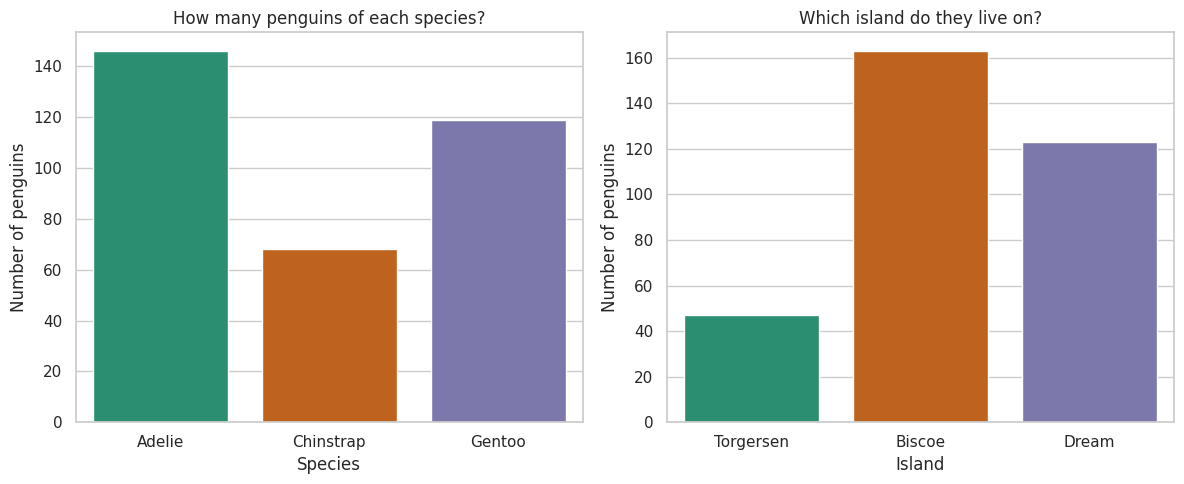

In [ ]:
# TODO (8): In a 1×2 grid, plot a countplot of 'species' and a countplot of 'island'.
# Give each a clear title.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='species', hue='species', palette='Dark2', legend=False, ax=axes[0])
axes[0].set_title('How many penguins of each species?')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Number of penguins')

sns.countplot(data=df, x='island', hue='island', palette='Dark2', legend=False, ax=axes[1])
axes[1].set_title('Which island do they live on?')
axes[1].set_xlabel('Island')
axes[1].set_ylabel('Number of penguins')

plt.tight_layout()
plt.show()

# Adelie is biggest grp then gentoo and in siland biscoe have most penguins.


island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0


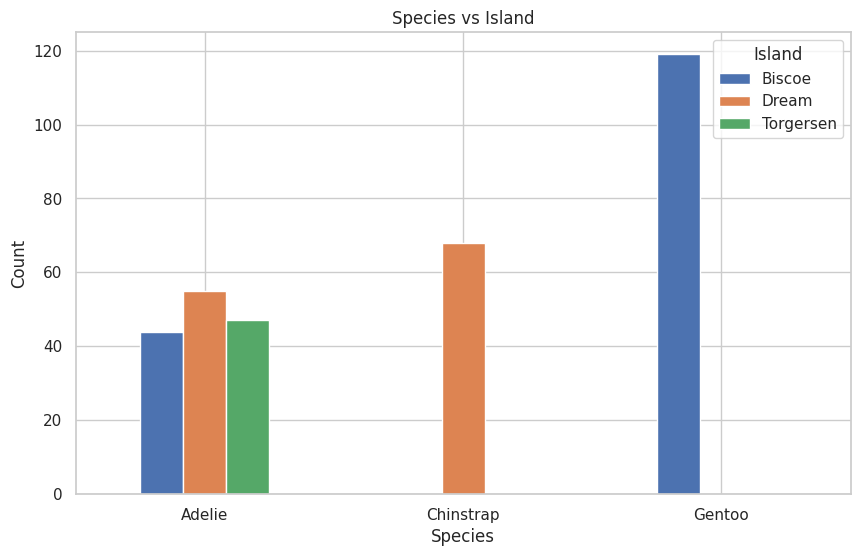

In [ ]:
# TODO (7): Make a crosstab of species vs island (pd.crosstab) and plot it as a bar chart.
# Which islands does each species live on?

ct = pd.crosstab(df['species'], df['island'])
print(ct)

ct.plot(kind='bar', figsize=(10, 6))

plt.title('Species vs Island')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Island')
plt.show()



**✍️ Written Answer C:** Which species is the most common? Is any species found on only ONE island? (That's a huge clue for identification.)
*Your answer:* _______________

Adelie is most common speccies found on all three islands. Gentoo is found only on Biscoe and chinstrap on dream

## Part D — Numerical EDA  *(20 marks)*
*Understand the four body measurements.*

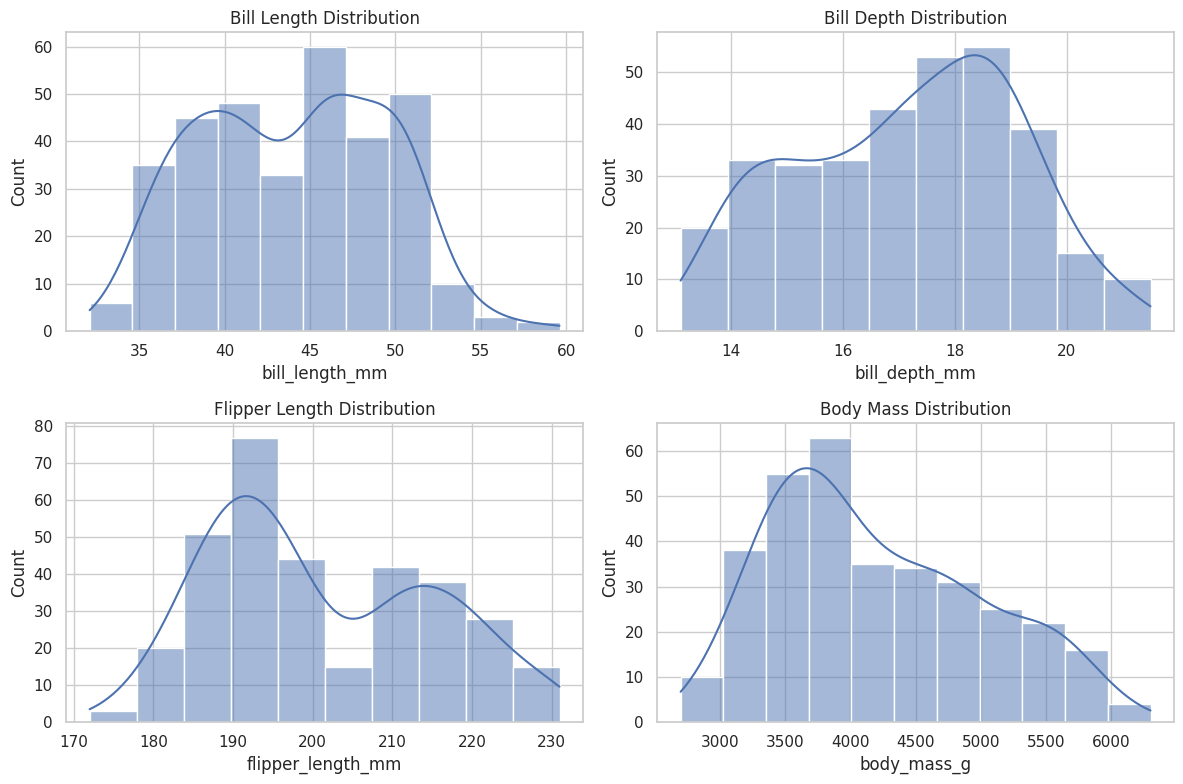

In [ ]:
# TODO (10): For each of the 4 measurements
#   (bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g),
# plot a histogram with kde=True. Arrange as a 2×2 grid.
# Look: are any distributions clearly split into groups (bumps)? That hints at species!

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Bill length
sns.histplot(df['bill_length_mm'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Bill Length Distribution")

# 2. Bill depth
sns.histplot(df['bill_depth_mm'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Bill Depth Distribution")

# 3. Flipper length
sns.histplot(df['flipper_length_mm'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Flipper Length Distribution")

# 4. Body mass
sns.histplot(df['body_mass_g'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Body Mass Distribution")

plt.tight_layout()
plt.show()

Bill length and flipper length show clear double bumps, meaning they likely separate species well flipper length especially has the widest gap between groups. Body mass and bill depth are less clean, so they're less reliable.

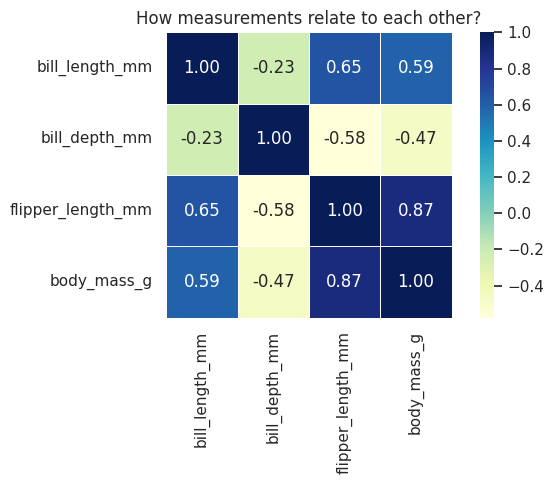

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  


In [ ]:
# TODO (10): Plot a correlation heatmap of the 4 numeric measurements (annot=True).
# Which two measurements are most strongly related?
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

plt.figure(figsize=(7, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, square=True)
plt.title('How measurements relate to each other?')
plt.tight_layout()
plt.show()

print(corr)


**✍️ Written Answer D:** Which two measurements have the strongest positive correlation, and does that make biological sense (think: bigger penguin → ?)
*Your answer:* _______________

Flipper length and body mass have the strongest positive correlation (0.87). This makes biological sense bigger, heavier penguins need longer flippers to swim and support their larger body size

## Part E — Species Fingerprints  *(25 marks)*  🎯 *the core of the assignment*
*This is where you crack the case: which measurements tell the species apart?*

In [ ]:
# TODO (9): Compute the MEAN of each measurement grouped by species.
#   df.groupby('species')[num_cols].mean()
# This table is the heart of your field guide — study it.

df.groupby('species')[num_cols].mean()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


Gentoo is easy to spot heaviest with the longest flippers. Adélie has the shortest bill, and bill depth separates the remaining two

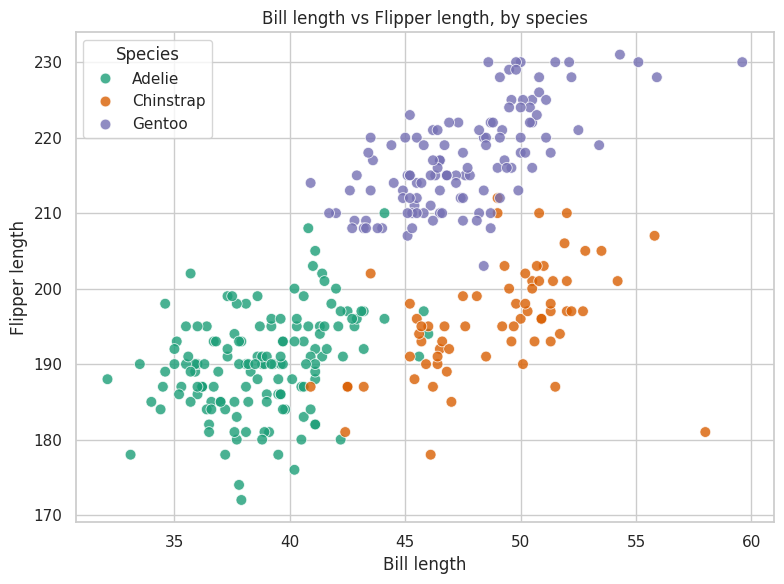

In [ ]:
# TODO (8): Make a scatter plot of bill_length_mm (x) vs flipper_length_mm (y),
# coloured by species (hue='species'). Do the species form separate clusters?

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species', palette='Dark2', alpha=0.8, s=60)
plt.title('Bill length vs Flipper length, by species')
plt.xlabel('Bill length')
plt.ylabel('Flipper length')
plt.legend(title='Species')

plt.tight_layout()
plt.show()


Gentoo separates clearly due to long flippers. Adélie and Chinstrap overlap more, but still split somewhat by bill length.

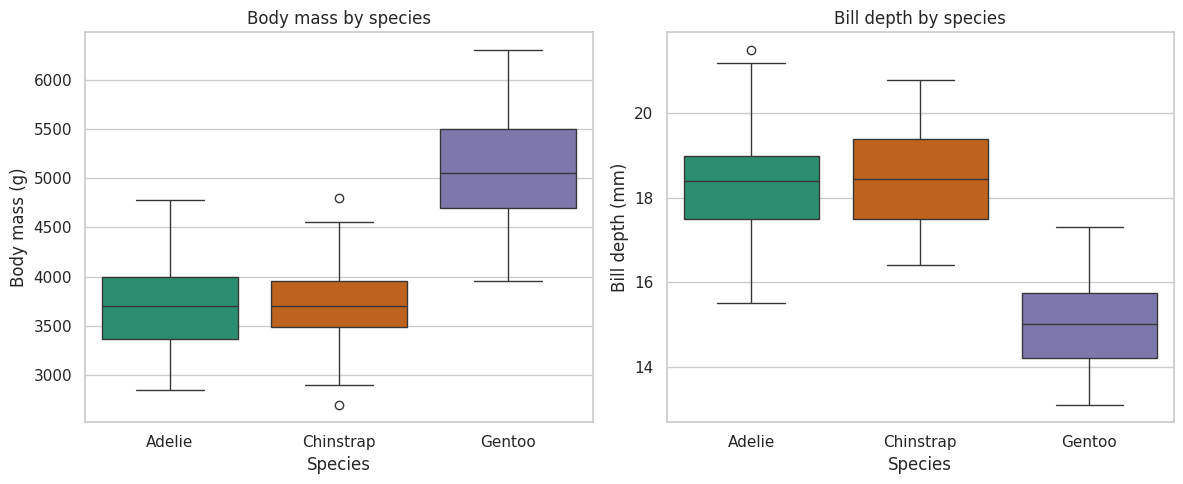

In [ ]:
# TODO (8): Make boxplots of body_mass_g by species, and bill_depth_mm by species
# (1×2 grid). Which species is the clear outlier in size?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='species', y='body_mass_g', hue='species', palette='Dark2', legend=False, ax=axes[0])
axes[0].set_title('Body mass by species')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Body mass (g)')

sns.boxplot(data=df, x='species', y='bill_depth_mm', hue='species', palette='Dark2', legend=False, ax=axes[1])
axes[1].set_title('Bill depth by species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Bill depth (mm)')

plt.tight_layout()
plt.show()


**✍️ Written Answer E:** Describe each species in ONE sentence using measurements. For example: *"Gentoos are the ___ (heaviest/lightest), with the ___ flippers and a ___ bill."* Do this for all three species.
*Adélie:* _______________
*Chinstrap:* _______________
*Gentoo:* _______________

Adélie: Lightest, with short flippers and a short bill.
Chinstrap: Medium weight, with short flippers but a long, deep bill.
Gentoo: Heaviest, with the longest flippers and a shallow bill.

## Part F — Your Field Guide  *(15 marks)*
Write a short **field guide** (4–6 sentences) that a junior researcher could use to identify a penguin from measurements alone. Base every rule on your charts. A good guide gives simple decision rules, e.g. *"If flipper length > 210mm, it's almost certainly a Gentoo."*

**✍️ Your Field Guide:**

> _______________________________________________
>
> _______________________________________________
>
> _______________________________________________

If flipper length > 210mm → almost certainly Gentoo. Their flippers are far longer than the other two species.

If body mass > 4500g → also Gentoo. They're clearly the heaviest species, with little overlap with the others.

If bill depth < 16mm → Gentoo again. Their bills are noticeably shallower than Adélie or Chinstrap.

If it's not Gentoo, check bill length: short bill → Adélie; long bill→ Chinstrap.

If bill length alone isn't enough: bill depth deeper leans Chinstrap, while shorter flippers leans Adélie.

only on Biscoe → Gentoo, only on Dream → Chinstrap, on any island → could be Adélie

## 🌟 Bonus — Identify the Mystery Penguin  *(+10 marks)*
A researcher measured a penguin but forgot to record its species:

> **bill_length = 46 mm, bill_depth = 15 mm, flipper_length = 217 mm, body_mass = 5000 g**

Using your fingerprints from Part E, decide which species it is — and **justify with the data** (which measurements gave it away?).

In [ ]:
# TODO (bonus): Justify your answer with code — e.g. compare this penguin's numbers
# to the species means, or plot it on top of your scatter from Part E.
# Species means

mystery = {'bill_length_mm': 46, 'bill_depth_mm': 15, 'flipper_length_mm': 217, 'body_mass_g': 5000}

species_means = df.groupby('species')[num_cols].mean()
print(species_means)
print("\nMystery penguin:", mystery)


           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.823973      18.347260         190.102740  3706.164384
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.568067      14.996639         217.235294  5092.436975

Mystery penguin: {'bill_length_mm': 46, 'bill_depth_mm': 15, 'flipper_length_mm': 217, 'body_mass_g': 5000}


**✍️ Bonus Answer:** This penguin is a **_______**, because _______________

This penguin is a Gentoo, because its flipper length (217mm), body mass (5000g), and bill depth (15mm) all closely match Gentoo's typical measurements.

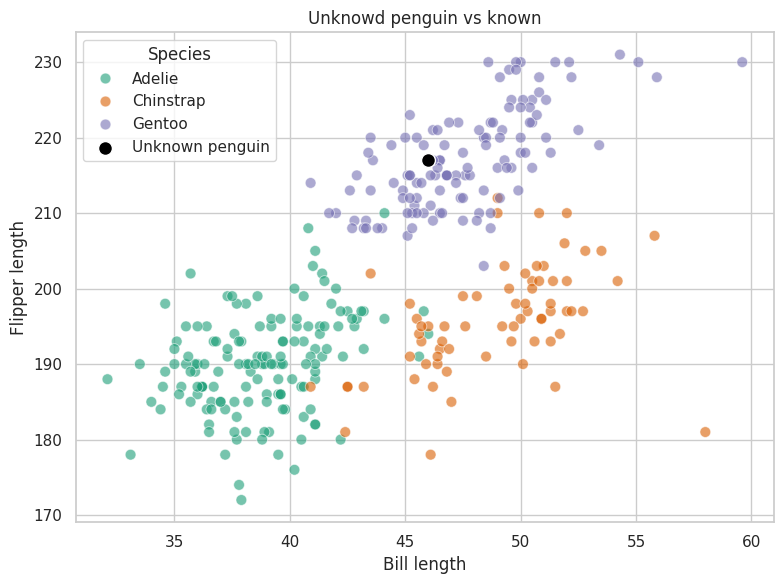

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species', palette='Dark2', alpha=0.6, s=60)

plt.scatter(46, 217, color='black', marker='.', s=400, label='Unknown penguin', edgecolor='white', linewidth=1)

plt.title('Unknowd penguin vs known')
plt.xlabel('Bill length')
plt.ylabel('Flipper length')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

---
### ✅ Before you submit
- [ ] Every `# TODO` cell has working code
- [ ] Every ✍️ Written Answer is filled in
- [ ] You ran **Kernel → Restart & Run All** with no errors
- [ ] Charts have titles and are readable

*Good luck, field biologist!* 🐧